In [3]:
import torch
torch.cuda.is_available()

True

In [7]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# --- STEP 1: COPY TO LOCAL DISK ---
if not os.path.exists('/content/dataset'):
    print("Copying files from Drive to local VM...")
    # Change the path below if your folder name is different
    !cp -r "/content/drive/MyDrive/dataset" /content/dataset
    print("Copying complete.")

BASE_DIR = "/content/dataset"

In [9]:
# Load CSV
df = pd.read_csv(f"{BASE_DIR}/english.csv")

# Encode labels (a-z, A-Z, 0-9)
label_encoder = LabelEncoder()
df['label_idx'] = label_encoder.fit_transform(df['label'])
num_classes = len(label_encoder.classes_)

# Split into Train and Validation sets
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label_idx'],
    random_state=42
)

print(f"Total classes: {num_classes}")
print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

Total classes: 62
Training samples: 2728
Validation samples: 682


In [32]:
class HandwritingDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.images = []
        self.labels = []
        self.transform = transform

        print(f"Pre-loading {len(dataframe)} images into RAM (resizing to 224 x 224)...")

        for idx in range(len(dataframe)):
            img_name = dataframe.iloc[idx, 0]
            label = dataframe.iloc[idx, 2] # This is the label_idx

            # Load the image
            img_path = os.path.join(BASE_DIR, img_name)
            image = Image.open(img_path).convert('RGB')

            # CRITICAL: Resize immediately before storing to save RAM
            image = image.resize((224, 224))

            self.images.append(image)
            self.labels.append(label)

            # Print progress every 500 images
            if (idx + 1) % 500 == 0:
                print(f"Loaded {idx + 1} images...")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        # Apply the remaining transforms (ToTensor and Normalize)
        if self.transform:
            image = self.transform(image)

        return image, label

In [33]:
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3), # Force it to ignore color noise
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.5), # Make strokes crisper
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1), scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = HandwritingDataset(train_df, transform=train_transforms)
val_dataset = HandwritingDataset(val_df, transform=val_transforms)

# Keep batch size at 64 or 128
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

Pre-loading 2728 images into RAM (resizing to 224 x 224)...
Loaded 500 images...
Loaded 1000 images...
Loaded 1500 images...
Loaded 2000 images...
Loaded 2500 images...
Pre-loading 682 images into RAM (resizing to 224 x 224)...
Loaded 500 images...


In [34]:
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

# Load EfficientNet_V2_S (much more powerful than ResNet18/50)
model = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.DEFAULT)

# Adjust the classifier head
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Loss with Label Smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# One Cycle Scheduler: It handles the LR automatically over the total steps
total_steps = len(train_loader) * 30 # 30 epochs
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.001, total_steps=total_steps)

In [35]:
best_val_acc = 0.0
num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step() # Move scheduler here for OneCycleLR

        running_loss += loss.item()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    print(f"Epoch {epoch+1} - Loss: {running_loss/len(train_loader):.4f} - Val Acc: {val_acc:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_handwriting_model_v2.pth')
        print(f"--> [NEW RECORD] Best model saved!")

Epoch 1 - Loss: 4.0845 - Val Acc: 9.97%
--> [NEW RECORD] Best model saved!
Epoch 2 - Loss: 3.4716 - Val Acc: 53.81%
--> [NEW RECORD] Best model saved!
Epoch 3 - Loss: 1.8838 - Val Acc: 83.14%
--> [NEW RECORD] Best model saved!
Epoch 4 - Loss: 1.2135 - Val Acc: 85.19%
--> [NEW RECORD] Best model saved!
Epoch 5 - Loss: 1.1767 - Val Acc: 82.40%
Epoch 6 - Loss: 1.1566 - Val Acc: 83.58%
Epoch 7 - Loss: 1.1582 - Val Acc: 80.06%
Epoch 8 - Loss: 1.1097 - Val Acc: 86.22%
--> [NEW RECORD] Best model saved!
Epoch 9 - Loss: 1.0683 - Val Acc: 85.48%
Epoch 10 - Loss: 1.0132 - Val Acc: 86.22%
Epoch 11 - Loss: 1.0082 - Val Acc: 87.68%
--> [NEW RECORD] Best model saved!
Epoch 12 - Loss: 0.9924 - Val Acc: 86.51%
Epoch 13 - Loss: 0.9667 - Val Acc: 87.68%
Epoch 14 - Loss: 0.9277 - Val Acc: 88.42%
--> [NEW RECORD] Best model saved!
Epoch 15 - Loss: 0.9106 - Val Acc: 87.10%
Epoch 16 - Loss: 0.9090 - Val Acc: 87.83%
Epoch 17 - Loss: 0.9147 - Val Acc: 86.36%
Epoch 18 - Loss: 0.8880 - Val Acc: 89.15%
--> [NEW 

Generating predictions...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.54      0.64      0.58        11
           1       0.70      0.64      0.67        11
           2       1.00      1.00      1.00        11
           3       1.00      1.00      1.00        11
           4       1.00      1.00      1.00        11
           5       1.00      0.91      0.95        11
           6       1.00      0.91      0.95        11
           7       1.00      1.00      1.00        11
           8       0.92      1.00      0.96        11
           9       0.90      0.82      0.86        11
           A       1.00      1.00      1.00        11
           B       1.00      1.00      1.00        11
           C       0.83      0.45      0.59        11
           D       0.92      1.00      0.96        11
           E       1.00      1.00      1.00        11
           F       0.92      1.00      0.96        11
           G       1.00 

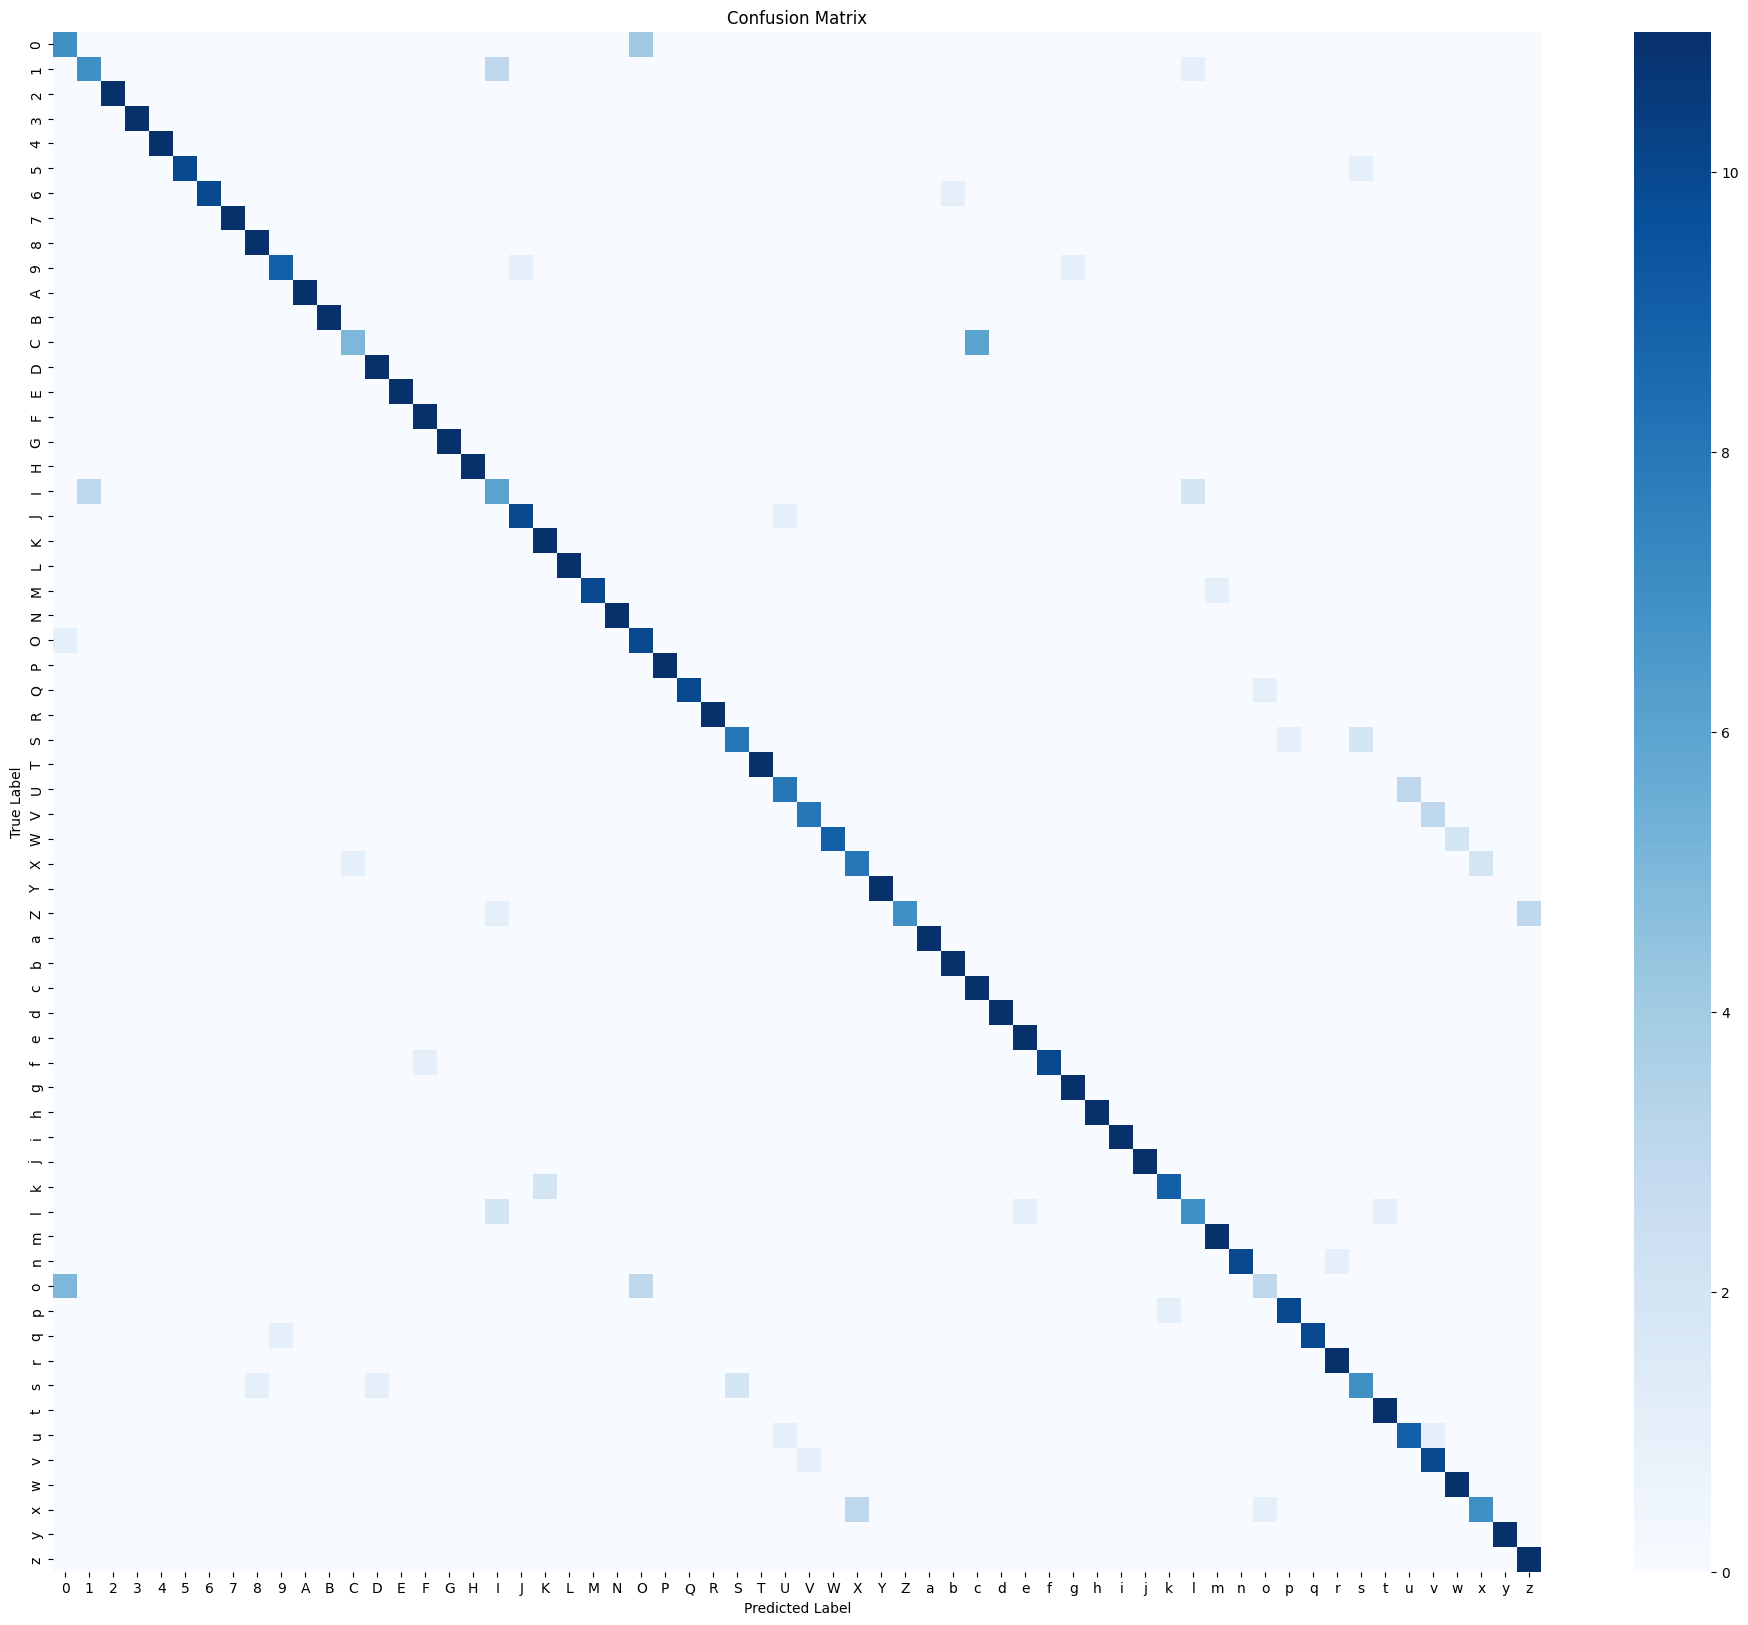

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. Load the best saved model
model.load_state_dict(torch.load('best_handwriting_model_v2.pth'))
model.eval()

all_preds = []
all_labels = []

# 2. Collect all predictions from validation set
print("Generating predictions...")
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Decode numeric indices back to actual characters (A, B, c, 1...)
target_names = label_encoder.classes_

# 4. Print Classification Report (Precision, Recall, F1)
print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds, target_names=target_names))

# 5. Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(24, 20)) # Large size because there are 62 classes
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [37]:
import pickle

# Save the model weights
torch.save(model.state_dict(), 'final_handwriting_model.pth')

# Save the label encoder (CRITICAL: you need this to translate numbers back to letters later)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("Project Complete! Model and Label Encoder saved.")

Project Complete! Model and Label Encoder saved.


In [38]:
np.save('classes.npy', label_encoder.classes_)
print("Classes saved to classes.npy")

Classes saved to classes.npy
